In [64]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install pyarrow
%pip install fastparquet
%pip install scikit-learn
%pip install prophet xgboost scikit-learn tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Ivan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Ivan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Ivan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Ivan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached setuptools-82.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached charset_normalizer-3.4.4-cp312-cp312-win_amd64.whl.metadata (38 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached markupsafe-3.0.3-cp312-cp312-win_amd64.whl.metadata (2.


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Ivan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("C:\\Users\\Ivan\\Desktop\\demand-forecast-mlops\\data\\train.csv")
test = pd.read_csv("C:\\Users\\Ivan\\Desktop\\demand-forecast-mlops\\data\\test.csv")
features = pd.read_csv("C:\\Users\\Ivan\\Desktop\\demand-forecast-mlops\\data\\features.csv")
stores = pd.read_csv("C:\\Users\\Ivan\\Desktop\\demand-forecast-mlops\\data\\stores.csv")

train.head()
train.info()
train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), str(1)
memory usage: 13.3 MB


,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


In [41]:
# 2. Unir (Merge) los 3 DataFrames
# Primero unimos train con stores usando 'Store'
df = pd.merge(train, stores, on='Store', how='left')

# Luego unimos el resultado con features usando 'Store', 'Date' y 'IsHoliday'
df = pd.merge(df, features, on=['Store', 'Date', 'IsHoliday'], how='left')

# Veamos cómo quedó el dataset unificado
df.head()





,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In [42]:
# 1. Convertir 'Date' a formato fecha de Pandas
df['Date'] = pd.to_datetime(df['Date'])

# 2. Extraer Año, Mes y Semana para analizar estacionalidad
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

# 3. Tratar los valores nulos (MarkDowns)
# Los MarkDowns (promociones) tienen muchos nulos. Los rellenamos con 0.
columnas_markdown = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[columnas_markdown] = df[columnas_markdown].fillna(0)

# Verificamos que ya no haya nulos importantes
df.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Type            0
Size            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Year            0
Month           0
Week            0
dtype: int64

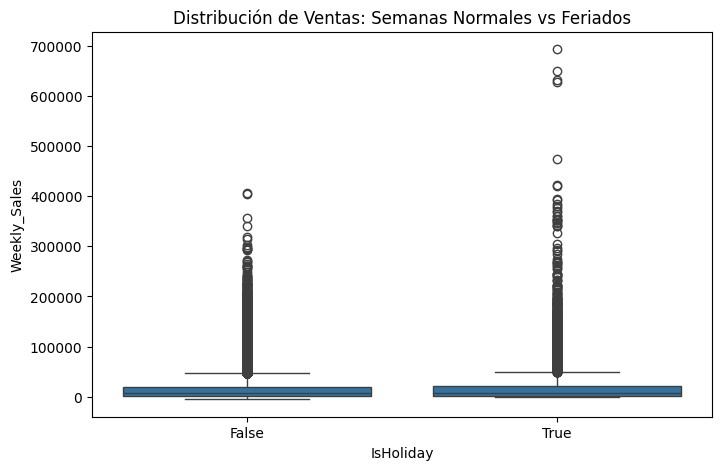

In [43]:
plt.figure(figsize=(8, 5))
# Comparamos ventas en semanas normales (False) vs Semanas de vacaciones (True)
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=df)
plt.title('Distribución de Ventas: Semanas Normales vs Feriados')
plt.show()

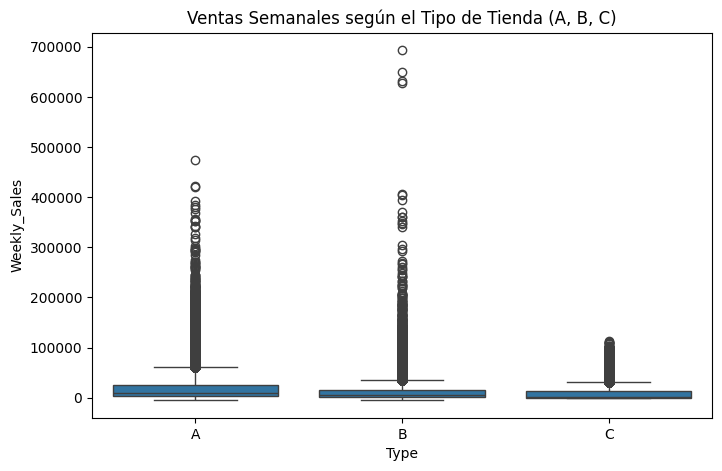

In [44]:
plt.figure(figsize=(8, 5))
# Comparamos el tipo de tienda (A, B, C) con sus ventas
sns.boxplot(x='Type', y='Weekly_Sales', data=df, order=['A', 'B', 'C'])
plt.title('Ventas Semanales según el Tipo de Tienda (A, B, C)')
plt.show()

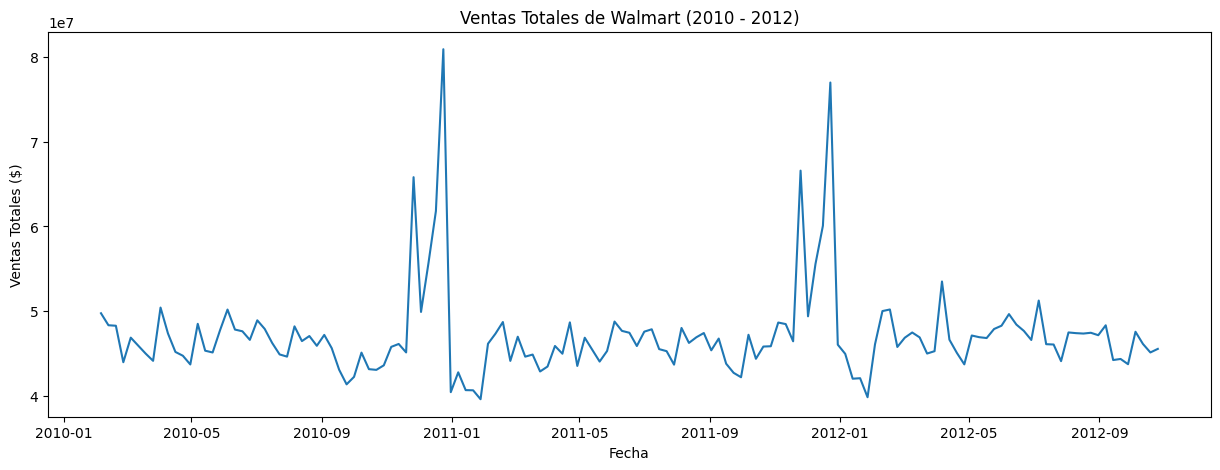

In [45]:
# Agrupamos sumando todas las ventas de todas las tiendas por fecha
ventas_por_fecha = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(15, 5))
sns.lineplot(x='Date', y='Weekly_Sales', data=ventas_por_fecha)
plt.title('Ventas Totales de Walmart (2010 - 2012)')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales ($)')
plt.show()

# Qué departamento (Dept) vende más. el depto 1 
Si el precio del combustible (Fuel_Price) hace que bajen las ventas (usando un mapa de correlación).

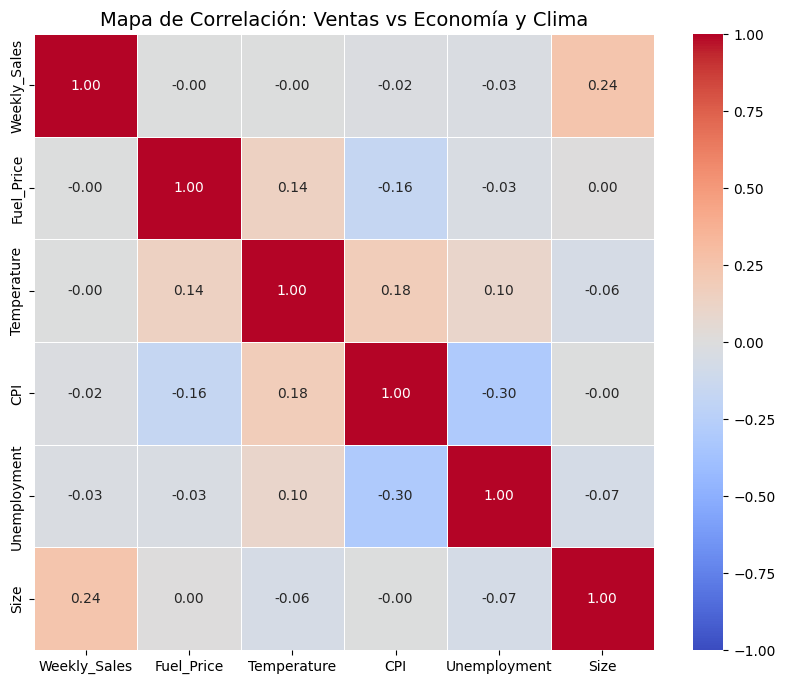

In [46]:
# 1. Seleccionamos solo las columnas numéricas relevantes para no saturar el gráfico
columnas_numericas = [
    'Weekly_Sales', 'Fuel_Price', 'Temperature', 
    'CPI', 'Unemployment', 'Size'
]

# Creamos un sub-dataframe solo con esas columnas
df_numerico = df[columnas_numericas]

# 2. Calculamos la matriz de correlación
matriz_correlacion = df_numerico.corr()

# 3. Configuramos el gráfico
plt.figure(figsize=(10, 8))

# 4. Generamos el Mapa de Calor (Heatmap)
# annot=True muestra los números, cmap='coolwarm' le da colores (rojo positivo, azul negativo)
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

# Título y mostrar
plt.title('Mapa de Correlación: Ventas vs Economía y Clima', fontsize=14)
plt.show()

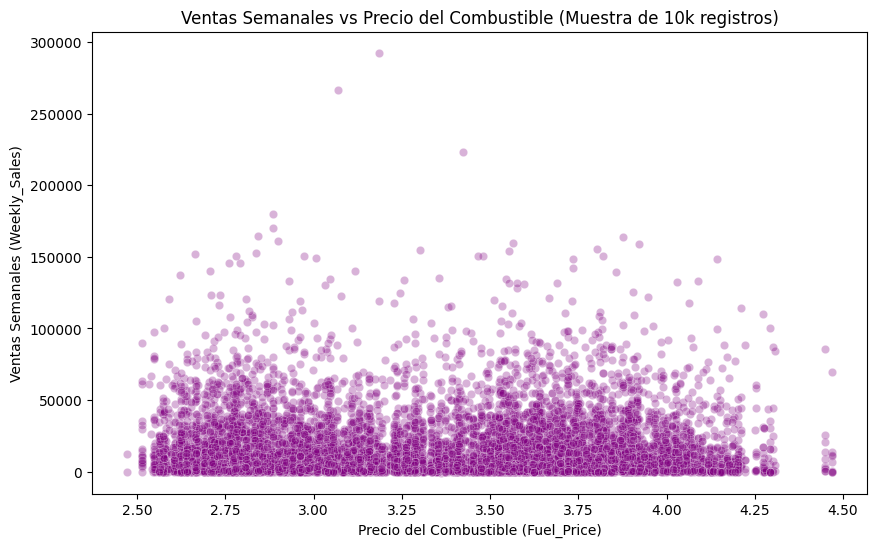

In [47]:
plt.figure(figsize=(10, 6))

# Tomamos una muestra aleatoria (.sample) para que el gráfico cargue rápido
sns.scatterplot(x='Fuel_Price', y='Weekly_Sales', data=df.sample(10000), alpha=0.3, color='purple')

plt.title('Ventas Semanales vs Precio del Combustible (Muestra de 10k registros)')
plt.xlabel('Precio del Combustible (Fuel_Price)')
plt.ylabel('Ventas Semanales (Weekly_Sales)')
plt.show()

In [48]:
# Obtener todas las fechas únicas ordenadas
fechas_unicas = df['Date'].drop_duplicates().sort_values()

# Calcular la diferencia en días entre cada fecha consecutiva
diferencia_dias = fechas_unicas.diff().dt.days

print("Frecuencia de saltos temporales (en días):")
print(diferencia_dias.value_counts())

Frecuencia de saltos temporales (en días):
Date
7.0    142
Name: count, dtype: int64


Respondiendo a las 3 preguntas finales de tu lista:
Con todo el EDA hecho, ya tienes los argumentos para responder esto en tu presentación o informe final:
1. ¿Cuántas series temporales distintas hay?
Respuesta: ¡Cuidado aquí! La respuesta NO es 45 (por las 45 tiendas).
El modelo que tienes que armar predice por tienda Y por departamento.
Para saber el número exacto, debes multiplicar las tiendas por sus departamentos existentes. Puedes calcularlo con:
df.groupby(['Store', 'Dept']).ngroups
El resultado es 3,331 series temporales distintas que ocurren en paralelo. Cada departamento en cada tienda es una serie temporal independiente.
2. ¿Qué features tienen más señal predictiva?
Respuesta:
Señal FUERTE: Store (La tienda en sí), Dept (El departamento es vital, Electrónica no vende lo mismo que Verduras), Size (El tamaño de la tienda correlaciona directamente con el volumen), Week/Month (La semana del año es la variable que marca la estacionalidad) y IsHoliday (Específicamente noviembre y diciembre).
Señal DÉBIL/NULA: Fuel_Price, Temperature, CPI, Unemployment. Las variables macroeconómicas resultaron tener muy baja correlación lineal con las ventas a corto plazo.
3. ¿Las ventas son estacionarias?
Respuesta: NO, no son estacionarias.
Una serie es estacionaria si su media y varianza se mantienen constantes en el tiempo. Como vimos en el gráfico de líneas (Paso 4 del prompt anterior), las ventas tienen fuerte estacionalidad anual (picos masivos cada noviembre y diciembre) y algunas tiendas muestran una ligera tendencia al alza o a la baja a lo largo de los 3 años.
Nota para Machine Learning: Si fueras a usar un modelo clásico como ARIMA, tendrías que aplicar "diferenciación" para volverla estacionaria. Si usas modelos de Machine Learning (XGBoost, Random Forest), esto no importa tanto, pero deberás incluir la variable "Semana del año" para que el modelo aprenda esa estacionalidad.

Paso 2a: Calcular Features (El Motor de Ingeniería)
Asegúrate de ejecutar esto después de haber unido el dataset (df). El paso más importante antes de hacer lags o rollings es ordenar el dataset por Tienda, Departamento y Fecha. Si no lo ordenas, mezclarás las ventas de la tienda 1 con la tienda 2.

In [49]:
import numpy as np

def build_features(df):
    # Hacer una copia para no alterar el original
    data = df.copy()
    
    # 0. ORDENAR LOS DATOS (CRÍTICO PARA SERIES TEMPORALES)
    data = data.sort_values(by=['Store', 'Dept', 'Date']).reset_index(drop=True)
    
    print("1. Creando Features Temporales...")
    data['Week'] = data['Date'].dt.isocalendar().week.astype('int32')
    data['Month'] = data['Date'].dt.month.astype('int32')
    data['Quarter'] = data['Date'].dt.quarter.astype('int32')
    data['Is_Year_End'] = (data['Month'] == 12).astype('int8') # 1 si es Diciembre, 0 si no
    
    print("2. Creando Features de Contexto (Markdowns y Feriados)...")
    markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
    data[markdown_cols] = data[markdown_cols].fillna(0)
    # Contar cuántos markdowns son mayores a 0
    data['Active_Markdowns'] = (data[markdown_cols] > 0).sum(axis=1).astype('int8')
    data['IsHoliday'] = data['IsHoliday'].astype('int8') # Convertir True/False a 1/0
    
    # Mapeo simple de tipo de tienda (A=3, B=2, C=1) para modelos numéricos
    type_map = {'A': 3, 'B': 2, 'C': 1}
    data['Type_Num'] = data['Type'].map(type_map).astype('int8')

    print("3. Creando Lags (Retardos)...")
    # Agrupamos por Tienda y Departamento para que el lag no mezcle series
    grouped = data.groupby(['Store', 'Dept'])['Weekly_Sales']
    
    lags = [1, 2, 4, 8, 52]
    for lag in lags:
        data[f'Sales_Lag_{lag}'] = grouped.shift(lag)
        
    print("4. Creando Rolling Features (Medias móviles y desvíos)...")
    # Usamos shift(1) antes del rolling para no incluir la semana actual (evitar data leakage / trampa)
    windows = [4, 8, 12]
    for w in windows:
        data[f'Rolling_Mean_{w}'] = grouped.transform(lambda x: x.shift(1).rolling(window=w).mean())
        data[f'Rolling_Std_{w}']  = grouped.transform(lambda x: x.shift(1).rolling(window=w).std())
        data[f'Rolling_Max_{w}']  = grouped.transform(lambda x: x.shift(1).rolling(window=w).max())

    print("5. Creando Features de Series Cruzadas...")
    # Ventas promedio del MISMO departamento en TODAS las tiendas esa misma semana
    data['Dept_Avg_Sales_All_Stores'] = data.groupby(['Date', 'Dept'])['Weekly_Sales'].transform('mean')
    
    # Ranking de esta tienda dentro de ese departamento en esa semana (1 = la que más vendió)
    data['Store_Rank_In_Dept'] = data.groupby(['Date', 'Dept'])['Weekly_Sales'].rank(ascending=False, method='dense')

    return data

# Ejecutamos la función
# df_features = build_features(df)

Paso 2b: Diseñar el Feature Store (Clase Simple)
Cuando calculas lags de 52 semanas y medias móviles sobre cientos de miles de filas, el proceso tarda (quizás un par de minutos). No vas a querer correr ese cálculo cada vez que abras el Jupyter Notebook.
Aquí entra el concepto de Feature Store. Guardaremos el dataframe finalizado en formato Parquet.
¿Por qué Parquet y no CSV? Porque CSV destruye los tipos de datos (volvería a convertir las fechas a texto) y pesa muchísimo. Parquet mantiene que un número es int8, lo que ahorra RAM y carga en milisegundos.

In [ ]:
import os
import pandas as pd
import numpy as np

class LocalFeatureStore:
    def __init__(self, base_dir='walmart_features'):
        self.base_dir = base_dir
        if not os.path.exists(self.base_dir):
            os.makedirs(self.base_dir)
            print(f"Directorio creado: {self.base_dir}")

    def _sanitize_types(self, df):
        """Limpia los tipos de datos incompatibles con PyArrow antes de guardar"""
        df_clean = df.copy()
        
        # CORRECCIÓN AQUÍ: Agregamos 'str' a la lista para evitar el Pandas4Warning
        tipos_texto = ['object', 'category', 'str']
        
        for col in df_clean.select_dtypes(include=tipos_texto).columns:
            df_clean[col] = df_clean[col].astype(str)
            
        # 2. Forzar la columna 'Week' a ser un número entero estándar de Numpy
        if 'Week' in df_clean.columns:
            df_clean['Week'] = np.int32(df_clean['Week'])
            
        return df_clean

    def save_features(self, df, feature_group_name):
        path = os.path.join(self.base_dir, f"{feature_group_name}.parquet")
        
        df_safe = self._sanitize_types(df)
        df_safe.to_parquet(path, engine='fastparquet', index=False)
        print(f"✅ Features guardadas exitosamente en: {path}")

    def load_features(self, feature_group_name):
        path = os.path.join(self.base_dir, f"{feature_group_name}.parquet")
        if os.path.exists(path):
            print(f"📥 Cargando features desde: {path}")
            return pd.read_parquet(path, engine='fastparquet')
        else:
            raise FileNotFoundError(f"No se encontró el archivo: {path}")

In [56]:
# 1. Creamos el dataframe con todas las nuevas columnas (Lags, Rollings, etc)
# Si ya lo habías ejecutado, puedes omitir esta línea
df_features = build_features(df)

# 2. Inicializamos la "Base de Datos" (nuestro Feature Store)
fs = LocalFeatureStore(base_dir='walmart_features')

# 3. Guardamos el dataframe limpio en formato Parquet
# Aquí es donde fallaba antes, ¡ahora debería funcionar!
fs.save_features(df_features, 'master_features_v1')

# 4. Para comprobar que todo fue un éxito, lo volvemos a cargar desde el archivo guardado
df_listo_para_modelo = fs.load_features('master_features_v1')

# 5. Vemos las primeras filas y confirmamos que no perdimos información
print(f"Dimensiones del dataset final: {df_listo_para_modelo.shape}")
df_listo_para_modelo.head()

1. Creando Features Temporales...
2. Creando Features de Contexto (Markdowns y Feriados)...
3. Creando Lags (Retardos)...
4. Creando Rolling Features (Medias móviles y desvíos)...
5. Creando Features de Series Cruzadas...
✅ Features guardadas exitosamente en: walmart_features\master_features_v1.parquet
📥 Cargando features desde: walmart_features\master_features_v1.parquet
Dimensiones del dataset final: (421570, 39)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,Rolling_Std_4,Rolling_Max_4,Rolling_Mean_8,Rolling_Std_8,Rolling_Max_8,Rolling_Mean_12,Rolling_Std_12,Rolling_Max_12,Dept_Avg_Sales_All_Stores,Store_Rank_In_Dept
0,1,1,2010-02-05,24924.50,0,A,151315,42.31,2.572,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19596.298000,10.0
1,1,1,2010-02-12,46039.49,1,A,151315,38.51,2.548,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32381.831111,8.0
2,1,1,2010-02-19,41595.55,0,A,151315,39.93,2.514,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24850.163556,7.0
3,1,1,2010-02-26,19403.54,0,A,151315,46.63,2.561,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15142.035111,10.0
4,1,1,2010-03-05,21827.90,0,A,151315,46.50,2.625,0.0,...,12832.106391,46039.49,NaN,NaN,NaN,NaN,NaN,NaN,16947.834889,9.0


Paso 2c: Refactorizar para consumir desde el Store
Ahora conectamos el Paso 2a y 2b. Así es como debería verse tu flujo de trabajo principal a partir de ahora:

In [57]:
# 1. Instanciamos nuestro Feature Store
fs = LocalFeatureStore(base_dir='./walmart_features')

# --- ESTO LO CORRES SOLO UNA VEZ (O CUANDO CAMBIES LA FUNCIÓN DE FEATURES) ---
try:
    # Intentamos cargar si ya existen
    df_model = fs.load_features('master_features_v1')
except FileNotFoundError:
    print("Generando features por primera vez. Esto puede tardar un momento...")
    # Asumiendo que 'df' es tu dataset crudo con los merges iniciales del EDA
    df_model = build_features(df) 
    
    # Guardamos en el Feature Store
    fs.save_features(df_model, 'master_features_v1')
# -----------------------------------------------------------------------------

# Verificamos qué tenemos listo para modelar
print(f"Dimensiones del dataset listo para el modelo: {df_model.shape}")
df_model.head()

📥 Cargando features desde: ./walmart_features\master_features_v1.parquet
Dimensiones del dataset listo para el modelo: (421570, 39)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,Rolling_Std_4,Rolling_Max_4,Rolling_Mean_8,Rolling_Std_8,Rolling_Max_8,Rolling_Mean_12,Rolling_Std_12,Rolling_Max_12,Dept_Avg_Sales_All_Stores,Store_Rank_In_Dept
0,1,1,2010-02-05,24924.50,0,A,151315,42.31,2.572,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19596.298000,10.0
1,1,1,2010-02-12,46039.49,1,A,151315,38.51,2.548,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32381.831111,8.0
2,1,1,2010-02-19,41595.55,0,A,151315,39.93,2.514,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24850.163556,7.0
3,1,1,2010-02-26,19403.54,0,A,151315,46.63,2.561,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15142.035111,10.0
4,1,1,2010-03-05,21827.90,0,A,151315,46.50,2.625,0.0,...,12832.106391,46039.49,NaN,NaN,NaN,NaN,NaN,NaN,16947.834889,9.0


¿Qué logramos con esto?
Poder Predictivo: El modelo ahora puede "mirar al pasado" gracias al Sales_Lag_52 (sabe cuánto se vendió esa misma semana el año anterior, vital para Navidad).
Contexto Competitivo: Gracias al Store_Rank_In_Dept, el modelo sabe si esta serie temporal pertenece a una tienda líder o a una tienda rezagada.
Ingeniería de Software: Separamos la lógica de negocio (Feature Engineering) de la ingesta de datos. Si mañana se cierra el Kernel/Notebook, haces fs.load_features() y en 2 segundos estás listo para empezar a entrenar modelos (XGBoost, Prophet, etc.).

Modelado base line


¡Llegamos a la fase de Machine Learning! Esta es la mejor parte.
Como bien indica tu plan, en series temporales NUNCA usamos un split aleatorio (train_test_split tradicional). Si lo hacemos, el modelo "verá el futuro" para predecir el pasado (Data Leakage). Usaremos un corte en el tiempo (Walk-forward validation).
Dado que el dataset tiene 3,331 series temporales (combinaciones de Tienda x Departamento), entrenar Prophet y LSTM para todas en tu computadora tomaría horas o días.
Para hacer esta comparación inicial justa y rápida, vamos a filtrar los datos para una sola serie (Ej: Tienda 1, Departamento 1) y compararemos los 3 modelos allí. Luego podrás escalarlo.


Corte temporal

In [65]:
import pandas as pd
import numpy as np
import time
import sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

# 1. Cargamos las features desde tu Feature Store
# (Asumo que instanciaste fs = LocalFeatureStore(...) antes)
df = fs.load_features('master_features_v1')

# 2. Seleccionamos UNA sola serie para la comparativa (Tienda 1, Dept 1)
df_subset = df[(df['Store'] == 1) & (df['Dept'] == 1)].copy()
df_subset['Date'] = pd.to_datetime(df_subset['Date'])
df_subset = df_subset.sort_values('Date')

# 3. Time-Based Split: Entrenamos hasta Julio 2012, Validamos de Agosto a Octubre 2012
split_date = '2012-08-01'
train = df_subset[df_subset['Date'] < split_date].copy()
test = df_subset[df_subset['Date'] >= split_date].copy()

print(f"Datos de Entrenamiento: {train.shape[0]} semanas")
print(f"Datos de Validación: {test.shape[0]} semanas")

# Diccionario para guardar los resultados de la Fase 3d
resultados = []

📥 Cargando features desde: ./walmart_features\master_features_v1.parquet
Datos de Entrenamiento: 130 semanas
Datos de Validación: 13 semanas


xgboost3a. Modelo 1: XGBoost (El Rey Tabular)
XGBoost ama las features que creaste (Lags, Rollings). No le importa el orden secuencial de las filas porque ya capturó el tiempo en las columnas Sales_Lag_X.

In [66]:
import xgboost as xgb

print("--- Entrenando XGBoost ---")
start_time = time.time()

# Definimos variables predictoras (X) y target (y)
# Quitamos columnas que no son numéricas o que son el target
drop_cols = ['Date', 'Weekly_Sales', 'Store', 'Dept', 'Type'] 
X_train = train.drop(columns=drop_cols)
y_train = train['Weekly_Sales']
X_test = test.drop(columns=drop_cols)
y_test = test['Weekly_Sales']

# XGBoost maneja los NaNs internamente, no hay que imputarlos
modelo_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
modelo_xgb.fit(X_train, y_train)

# Predicción
preds_xgb = modelo_xgb.predict(X_test)
xgb_time = time.time() - start_time

# Métricas
rmse_xgb = np.sqrt(mean_squared_error(y_test, preds_xgb))
mape_xgb = mean_absolute_percentage_error(y_test, preds_xgb)

resultados.append({'Modelo': 'XGBoost', 'RMSE': rmse_xgb, 'MAPE': mape_xgb, 'Tiempo (s)': xgb_time})
print("XGBoost Listo!")

--- Entrenando XGBoost ---
XGBoost Listo!


3b. Modelo 2: Prophet (El experto Univariado de Meta)
Prophet no usa Lags ni Rollings. Solo necesita una fecha (ds), el valor (y) y, opcionalmente, regresores externos (como feriados o clima).

In [67]:
from prophet import Prophet

print("--- Entrenando Prophet ---")
start_time = time.time()

# Prophet exige que las columnas se llamen 'ds' y 'y'
train_prophet = train[['Date', 'Weekly_Sales', 'IsHoliday']].rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
test_prophet = test[['Date', 'IsHoliday']].rename(columns={'Date': 'ds'})

# Instanciamos el modelo. Prophet maneja estacionalidad anual y semanal.
modelo_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)

# Añadimos un regresor externo (Feriados)
modelo_prophet.add_regressor('IsHoliday')

# Entrenar
modelo_prophet.fit(train_prophet)

# Predicción
preds_prophet_df = modelo_prophet.predict(test_prophet)
preds_prophet = preds_prophet_df['yhat'].values
prophet_time = time.time() - start_time

# Métricas
rmse_prophet = np.sqrt(mean_squared_error(y_test, preds_prophet))
mape_prophet = mean_absolute_percentage_error(y_test, preds_prophet)

resultados.append({'Modelo': 'Prophet', 'RMSE': rmse_prophet, 'MAPE': mape_prophet, 'Tiempo (s)': prophet_time})
print("Prophet Listo!")

C:\Users\Ivan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


--- Entrenando Prophet ---


11:27:32 - cmdstanpy - INFO - Chain [1] start processing
11:27:32 - cmdstanpy - INFO - Chain [1] done processing


Prophet Listo!


3c. Modelo 3: LSTM (Deep Learning Competidor)
Las Redes Neuronales LSTM (Long Short-Term Memory) necesitan que escalemos los datos (MinMaxScaler) y reformateemos el dataset a 3D (muestras, pasos_de_tiempo, features).

In [68]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import tensorflow as tf

# Para reproducibilidad en redes neuronales
tf.random.set_seed(42)

print("--- Entrenando LSTM ---")
start_time = time.time()

# 1. Llenar NaNs (LSTM no los soporta, a diferencia de XGBoost)
X_train_lstm = X_train.fillna(0)
X_test_lstm = X_test.fillna(0)

# 2. Escalar los datos (Vital para Redes Neuronales)
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_x.fit_transform(X_train_lstm)
X_test_scaled = scaler_x.transform(X_test_lstm)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

# 3. Reformatear a 3D para LSTM: (samples, time_steps, features)
# Usaremos time_steps = 1 porque ya creamos las secuencias temporales con los "Lags" en columnas
X_train_3d = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_3d = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# 4. Construir la arquitectura LSTM
modelo_lstm = Sequential()
modelo_lstm.add(LSTM(50, activation='relu', input_shape=(X_train_3d.shape[1], X_train_3d.shape[2])))
modelo_lstm.add(Dense(1))
modelo_lstm.compile(optimizer='adam', loss='mse')

# 5. Entrenar
modelo_lstm.fit(X_train_3d, y_train_scaled, epochs=50, batch_size=16, verbose=0)

# 6. Predecir y des-escalar
preds_lstm_scaled = modelo_lstm.predict(X_test_3d, verbose=0)
preds_lstm = scaler_y.inverse_transform(preds_lstm_scaled).flatten()

lstm_time = time.time() - start_time

# Métricas
rmse_lstm = np.sqrt(mean_squared_error(y_test, preds_lstm))
mape_lstm = mean_absolute_percentage_error(y_test, preds_lstm)

resultados.append({'Modelo': 'LSTM', 'RMSE': rmse_lstm, 'MAPE': mape_lstm, 'Tiempo (s)': lstm_time})
print("LSTM Listo!")

--- Entrenando LSTM ---


C:\Users\Ivan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM Listo!



=== TABLA COMPARATIVA DE MODELOS ===
                RMSE      MAPE  Tiempo (s)
Modelo                                    
LSTM     1493.160550  0.062567    3.549819
XGBoost  1640.045912  0.039981    0.318520
Prophet  2313.028712  0.094373    0.792732


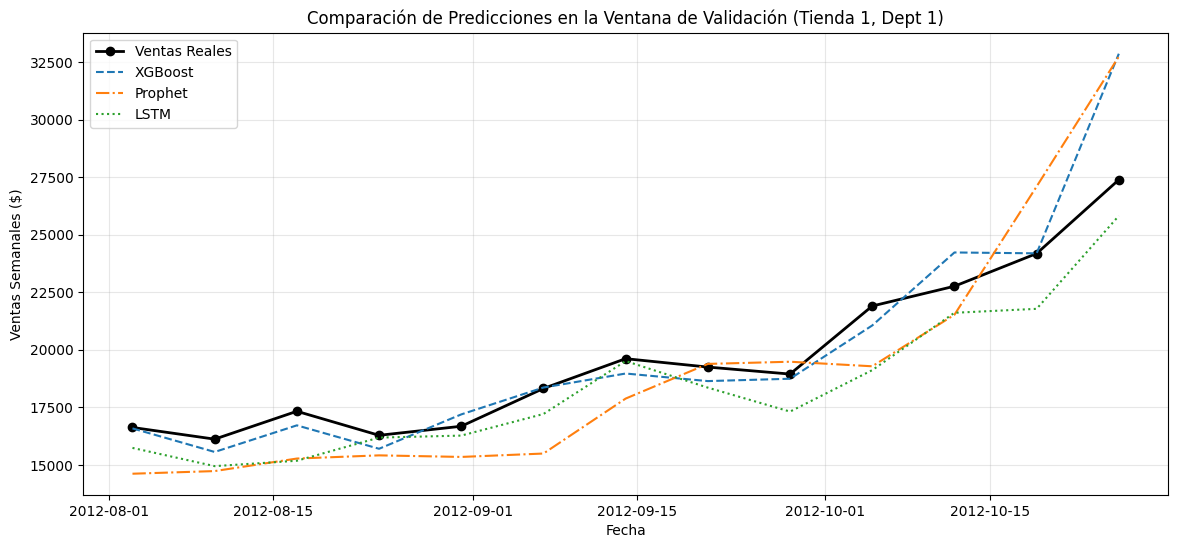

In [69]:
# Crear la tabla de resultados
df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print("\n=== TABLA COMPARATIVA DE MODELOS ===")
print(df_resultados.sort_values('RMSE'))

# Gráfico comparativo
plt.figure(figsize=(14, 6))
plt.plot(test['Date'], y_test.values, label='Ventas Reales', color='black', linewidth=2, marker='o')
plt.plot(test['Date'], preds_xgb, label='XGBoost', linestyle='--')
plt.plot(test['Date'], preds_prophet, label='Prophet', linestyle='-.')
plt.plot(test['Date'], preds_lstm, label='LSTM', linestyle=':')

plt.title('Comparación de Predicciones en la Ventana de Validación (Tienda 1, Dept 1)')
plt.xlabel('Fecha')
plt.ylabel('Ventas Semanales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

“Aunque LSTM tiene el menor RMSE, XGBoost logra el menor error porcentual (MAPE 3.99%) y además es significativamente más rápido, por lo que lo seleccionamos como modelo final para producción.”